# Árvores II - Tarefa 2

### 1. Carregar as bases

Vamos carregar as bases lidas na tarefa passada. Se você salvou essas bases em arquivo texto, basta fazer a leitura com o comando ```pd.read_csv``` das seguintes bases:

- X_train
- Y_train
- X_test
- Y_test

Não se esqueça de considerar a leitura dos índices dos arquivos no ```read_csv()```!

In [19]:
import pandas as pd  # Biblioteca para manipulação e análise de dados, especialmenet Dataframes e Series
import seaborn as sns  # Biblioteca para visualização dos dados, baseado em matplotlib, com gráficos estátisticos aprimorados
import matplotlib.pyplot as plt  # Biblioteca principal para criação de gráficos em python
import numpy as np  # Biblioteca para operações matemáticas e manipulação de arrays numéricos

from sklearn.tree import (
    DecisionTreeClassifier,
)  # Importa o classificador de árvore de decisão do scikit-learn
from sklearn.model_selection import (
    train_test_split,
)  # Função para dividir os dados em treino, validação e teste
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)  # Funções para calcular e exibir matrizes de confusão

In [20]:
features_path = "./input/features.txt" # Definição de caminho para feature.txt, arquivo que guarda o nome de cada coluna do dataframe
subject_train_series_path = "./input/train/subject_train.txt"  # Definição de caminho para subject_train.txt, arquivo que guarda a identificação do usuário em cada linha
x_train_path = "./input/train/X_train.txt" # Definição de caminho para X_train.txt, arquivo que armazena as variáveis explicativas com os dados dos sensores
y_train_path = "./input/train/y_train.txt" # Definição de caminho para y_train.txt, arquivo com os rótulos de cada leitura

x_test_path = "./input/test/X_test.txt" # Definição de caminho para X_test.txt, arquivo que armazena as variáveis explicativas dos os dados coletados por sensores
y_test_path = "./input/test/y_test.txt" # Definição de caminho para y_train.txt, arquivo com os rótulos de cada leitura
subject_test_path = "./input/test/subject_test.txt"

In [21]:
# Carrega o arquivo de features (nomes das variáveis) a partir de um arquivo separado por tabulação ("\t")
# O parâmetro header=None indica que o arquivo não possui cabeçalho.
# O índice [0] é usado para selecionar apenas a primeira coluna, convertendo-a em uma Série do pandas.
features = pd.read_csv(features_path, delimiter="\t", header=None)[0]

# Carrega os identificadores dos sujeitos (indivíduos participantes) do conjunto de treinamento
# Assim como acima, o arquivo é separado por tabulação, não tem cabeçalho e apenas a primeira coluna é selecionada.
subject_train = pd.read_csv(subject_train_series_path, delimiter="\t", header=None)[0]

# Carrega os dados do conjunto de treinamento
# O parâmetro `delim_whitespace=True` indica que os valores são separados por espaços em branco.
# Como o arquivo não tem cabeçalho, `header=None` é usado.
# O argumento `names=features` define os nomes das colunas usando os valores da Série `features`.
x_train = pd.read_csv(x_train_path, delim_whitespace=True, header=None, names=features)

# Carrega os rótulos (labels) do conjunto de treinamento
# O formato é semelhante ao de `x_train`, mas sem nomes de colunas definidos.
y_train = pd.read_csv(y_train_path, delim_whitespace=True, header=None)

# Carrega os identificadores dos sujeitos do conjunto de teste
subject_test = pd.read_csv(subject_test_path, delimiter="\t", header=None)[0]

# Carrega os dados do conjunto de teste, com o mesmo formato do conjunto de treinamento
x_test = pd.read_csv(x_test_path, delim_whitespace=True, header=None, names=features)

# Carrega os rótulos do conjunto de teste
y_test = pd.read_csv(y_test_path, delim_whitespace=True, header=None)

C:\Users\hfasa\AppData\Local\Temp\ipykernel_28964\234015118.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  x_train = pd.read_csv(x_train_path, delim_whitespace=True, header=None, names=features)
C:\Users\hfasa\AppData\Local\Temp\ipykernel_28964\234015118.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(y_train_path, delim_whitespace=True, header=None)
C:\Users\hfasa\AppData\Local\Temp\ipykernel_28964\234015118.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  x_test = pd.read_csv(x_test_path, delim_whitespace=True, header=None, names=features)
C:\Users\hfasa\AppData\Local\Temp\ipykernel_28964\234015118.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.re

In [22]:
# Cria um DataFrame a partir de `x_train`, que contém os dados de treino com as variáveis já nomeadas.
dataframe_treino = (
    pd.DataFrame(x_train)  # Converte `x_train` em um DataFrame do pandas
    .assign(Indivíduos=subject_train)  # Adiciona a coluna "Indivíduos" com os identificadores dos participantes
    .assign(Atividades=y_train)  # Adiciona a coluna "Atividades" com os rótulos (labels) das atividades realizadas
    .set_index("Indivíduos", append=True)  # Define a coluna "Indivíduos" como índice, mantendo o índice existente
)

# Exibe o DataFrame resultante
dataframe_treino

,,1 tBodyAcc-mean()-X,2 tBodyAcc-mean()-Y,3 tBodyAcc-mean()-Z,4 tBodyAcc-std()-X,5 tBodyAcc-std()-Y,6 tBodyAcc-std()-Z,7 tBodyAcc-mad()-X,8 tBodyAcc-mad()-Y,9 tBodyAcc-mad()-Z,10 tBodyAcc-max()-X,...,553 fBodyBodyGyroJerkMag-skewness(),554 fBodyBodyGyroJerkMag-kurtosis(),"555 angle(tBodyAccMean,gravity)","556 angle(tBodyAccJerkMean),gravityMean)","557 angle(tBodyGyroMean,gravityMean)","558 angle(tBodyGyroJerkMean,gravityMean)","559 angle(X,gravityMean)","560 angle(Y,gravityMean)","561 angle(Z,gravityMean)",Atividades
,Indivíduos,,,,,,,,,,,,,,,,,,,,,
0,1,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5
1,1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5
2,1,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5
3,1,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5
4,1,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,30,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,2
7348,30,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,2
7349,30,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,2


In [23]:
# Criação de um DataFrame a partir da variável x_test
dataframe_teste = (
    pd.DataFrame(x_test)  
    # Adiciona uma nova coluna chamada "Indivíduos" com os valores de subject_test
    .assign(Indivíduos=subject_test)  
    # Adiciona uma nova coluna chamada "Atividades" com os valores de y_test
    .assign(Atividades=y_test)  
    # Define a coluna "Indivíduos" como índice secundário, mantendo o índice original
    .set_index("Indivíduos", append=True)  
)

# Exibe o DataFrame resultante
dataframe_teste

,,1 tBodyAcc-mean()-X,2 tBodyAcc-mean()-Y,3 tBodyAcc-mean()-Z,4 tBodyAcc-std()-X,5 tBodyAcc-std()-Y,6 tBodyAcc-std()-Z,7 tBodyAcc-mad()-X,8 tBodyAcc-mad()-Y,9 tBodyAcc-mad()-Z,10 tBodyAcc-max()-X,...,553 fBodyBodyGyroJerkMag-skewness(),554 fBodyBodyGyroJerkMag-kurtosis(),"555 angle(tBodyAccMean,gravity)","556 angle(tBodyAccJerkMean),gravityMean)","557 angle(tBodyGyroMean,gravityMean)","558 angle(tBodyGyroJerkMean,gravityMean)","559 angle(X,gravityMean)","560 angle(Y,gravityMean)","561 angle(Z,gravityMean)",Atividades
,Indivíduos,,,,,,,,,,,,,,,,,,,,,
0,2,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,5
1,2,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,5
2,2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,5
3,2,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,5
4,2,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,24,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2
2943,24,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2
2944,24,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2


In [24]:
# Concatena os DataFrames dataframe_treino e dataframe_teste ao longo do eixo das linhas (axis=0)
df1 = pd.concat([dataframe_treino, dataframe_teste], axis=0, ignore_index=True)


### 2. Divisão da base em Treino, Validação e Teste

A base já se encontra dividida em Treino e Validação. O que vamos fazer então é extrair uma base de Validação da base de Treino.

Extraia 25% da base de treino como base de validação.

In [25]:
# Remove a coluna "Atividades" do DataFrame e armazena o restante das colunas em X
X = df1.drop(columns=["Atividades"])

# Seleciona apenas a coluna "Atividades" e a armazena em y
y = df1["Atividades"]


In [26]:
# Divide os dados em conjunto de treino (80%) e teste (20%)
X_, X_test, y_, y_test = train_test_split(X, y, test_size=0.2, random_state=2360873)

# Divide os dados de treino em treino (75%) e validação (25%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_, y_, test_size=0.25, random_state=2360873
)


### 3. Melhores 3 variáveis

Rode uma árvore com profundidade máxima igual a 4 para prever a atividade humana com todas as variáveis.
Observe a importância das variáveis e considere as 3 variáveis com maior importância para os próximos passos.
Dica: utilize o atributo ```clf.feature_importances_``` da árvore treinada.

In [27]:
# Cria um classificador de árvore de decisão com profundidade máxima de 4
clf0 = DecisionTreeClassifier(max_depth=4, random_state=2510895)

# Treina o classificador com os dados de treino
clf0.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=2510895)

In [28]:
# Retorna a importância de cada feature no modelo treinado
clf0.feature_importances_


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.14903237, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.28385734, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.12506992,
       0.        , 0.        , 0.        , 0.        , 0.     

In [29]:
# Obtém os nomes das colunas do DataFrame X
colunas = X.columns

# Obtém a importância das features do modelo treinado
importancia = clf0.feature_importances_

# Cria um DataFrame com as colunas e suas respectivas importâncias
df_top3_var = pd.DataFrame({"Colunas": colunas, "variaveis": importancia})

# Ordena o DataFrame pela importância das variáveis em ordem decrescente
df_top3_var = df_top3_var.sort_values(by="variaveis", ascending=False)

# Exibe o DataFrame resultante
df_top3_var


,Colunas,variaveis
52,53 tGravityAcc-min()-X,0.283857
366,367 fBodyAccJerk-entropy()-X,0.263302
41,42 tGravityAcc-mean()-Y,0.149032
201,202 tBodyAccMag-std(),0.140433
69,"70 tGravityAcc-arCoeff()-Y,1",0.125070
...,...,...
183,184 tBodyGyroJerk-entropy()-Y,0.000000
182,183 tBodyGyroJerk-entropy()-X,0.000000
181,182 tBodyGyroJerk-iqr()-Z,0.000000
180,181 tBodyGyroJerk-iqr()-Y,0.000000


In [30]:
# Cria uma lista com os nomes das colunas que serão selecionadas do DataFrame
filtro_de_colunas = ['53 tGravityAcc-min()-X', '272 fBodyAcc-mad()-X', '560 angle(Y,gravityMean)']

# Seleciona apenas as colunas especificadas na lista filtro_de_colunas
X = df1[filtro_de_colunas]


In [31]:
# Divide os dados em conjunto de treino (80%) e teste (20%)
X_, X_test, y_, y_test = train_test_split(X, y, test_size=0.2, random_state=2360873)

# Divide os dados de treino em treino (75%) e validação (25%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_, y_, test_size=0.25, random_state=2360873
)


### 4. Construa uma árvore com as 3 melhores variáveis

Utilizando as três variáveis encontradas acima, construa uma árvore de decisão. Encontre o melhor ```ccp_alpha``` utilizando a base de validação, conforme a estrutura que vimos em aula.

In [32]:
# Calcula o caminho de poda de complexidade de custo para a árvore de decisão
caminho = DecisionTreeClassifier(random_state=2360873).cost_complexity_pruning_path(X_train, y_train)

# Extrai os valores de ccp_alphas (valores de poda) e impurities (impurezas) do caminho
ccp_alphas, impurities = caminho.ccp_alphas, caminho.impurities


In [33]:
# Cria uma lista vazia para armazenar os modelos de árvore de decisão podados
clfs = []

# Itera sobre os valores de ccp_alpha para treinar uma árvore de decisão para cada valor de poda
for ccp_alpha in ccp_alphas:
    # Cria e treina um classificador de árvore de decisão com o valor atual de ccp_alpha
    clf = DecisionTreeClassifier(random_state=2360873, ccp_alpha=ccp_alpha).fit(X_train, y_train)
    
    # Adiciona o classificador treinado à lista clfs
    clfs.append(clf)


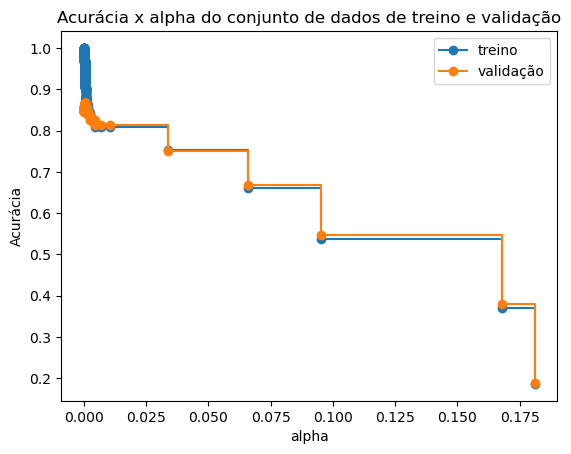

In [34]:
# Calcula a acurácia para cada árvore treinada no conjunto de treino (X_train, y_train)
train_scores = [clf.score(X_train, y_train) for clf in clfs]

# Calcula a acurácia para cada árvore treinada no conjunto de validação (X_valid, y_valid)
valid_scores = [clf.score(X_valid, y_valid) for clf in clfs]

# Cria uma figura e um eixo para o gráfico
fig, ax = plt.subplots()

# Define os rótulos dos eixos
ax.set_xlabel("alpha")  # Rótulo do eixo X
ax.set_ylabel("Acurácia")  # Rótulo do eixo Y
ax.set_title("Acurácia x alpha do conjunto de dados de treino e validação")  # Título do gráfico

# Plota a acurácia para o conjunto de treino em função de ccp_alpha
ax.plot(ccp_alphas, train_scores, marker='o', label="treino", drawstyle="steps-post")

# Plota a acurácia para o conjunto de validação em função de ccp_alpha
ax.plot(ccp_alphas, valid_scores, marker='o', label="validação", drawstyle="steps-post")

# Adiciona a legenda ao gráfico
ax.legend()

# Exibe o gráfico
plt.show()


In [35]:
# Encontra o índice da melhor árvore, que é aquela com a maior acurácia no conjunto de validação
ind_melhor_arvore = len(valid_scores) - valid_scores[::-1].index(max(valid_scores)) - 1

# Seleciona o modelo correspondente à melhor árvore
melhor_arvore = clfs[ind_melhor_arvore]

# Exibe a acurácia da melhor árvore no conjunto de validação
print(f'Acurácia da melhor árvore na base de validação: {valid_scores[ind_melhor_arvore]*100:.2f}')

# Exibe o modelo da melhor árvore
melhor_arvore


Acurácia da melhor árvore na base de validação: 86.75


DecisionTreeClassifier(ccp_alpha=0.00032778715413445955, random_state=2360873)

### 5. Avaliação do modelo

Avalie a árvore encontrada no item anterior na base de testes.

Acurácia: 86.89


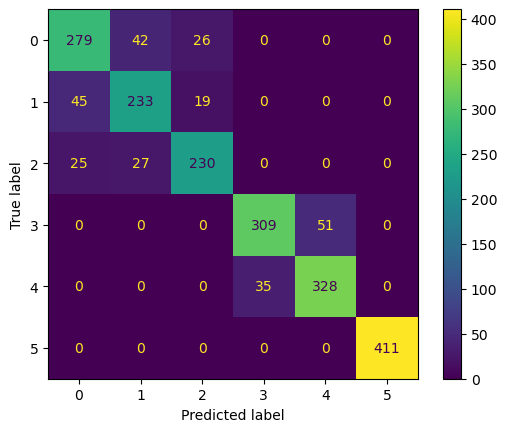

In [36]:
# Calcula a acurácia da melhor árvore no conjunto de teste
acuracia_teste = melhor_arvore.score(X_test, y_test)

# Exibe a acurácia da melhor árvore no conjunto de teste, formatada como porcentagem
print(f'Acurácia: {acuracia_teste*100:.2f}')

# Calcula a matriz de confusão para as predições no conjunto de teste
cm = confusion_matrix(y_test, melhor_arvore.predict(X_test))

# Cria uma visualização da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plota a matriz de confusão
disp.plot()
